In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/processed/telco_customer_churn_clean.csv")

In [3]:
df.shape

(7043, 26)

In [4]:
df.head()

,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV
0,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3239
1,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2701
2,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,5372
3,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,5003
4,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,5340


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Zip Code           7043 non-null   int64  
 2   Lat Long           7043 non-null   object 
 3   Latitude           7043 non-null   float64
 4   Longitude          7043 non-null   float64
 5   Gender             7043 non-null   object 
 6   Senior Citizen     7043 non-null   object 
 7   Partner            7043 non-null   object 
 8   Dependents         7043 non-null   object 
 9   Tenure Months      7043 non-null   int64  
 10  Phone Service      7043 non-null   object 
 11  Multiple Lines     7043 non-null   object 
 12  Internet Service   7043 non-null   object 
 13  Online Security    7043 non-null   object 
 14  Online Backup      7043 non-null   object 
 15  Device Protection  7043 non-null   object 
 16  Tech Support       7043 

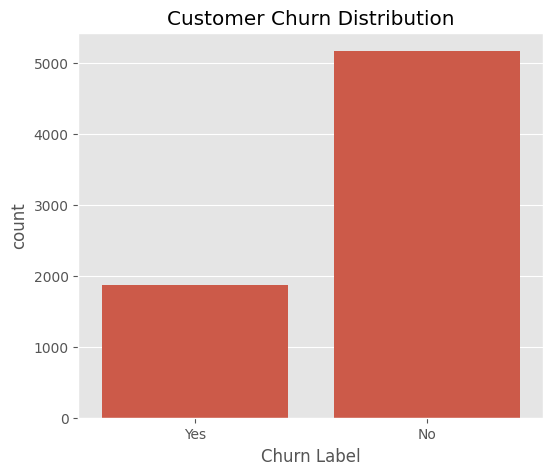

In [6]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Churn Label"
)

plt.title("Customer Churn Distribution")

plt.show()

In [7]:
df["Churn Label"].value_counts(normalize=True)*100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Observation 1: Customer Churn Distribution

Approximately 26.5% of customers in the dataset have churned, while 73.5% have remained with the company. This indicates that although most customers stay, a significant proportion leave, making churn prediction an important business problem.


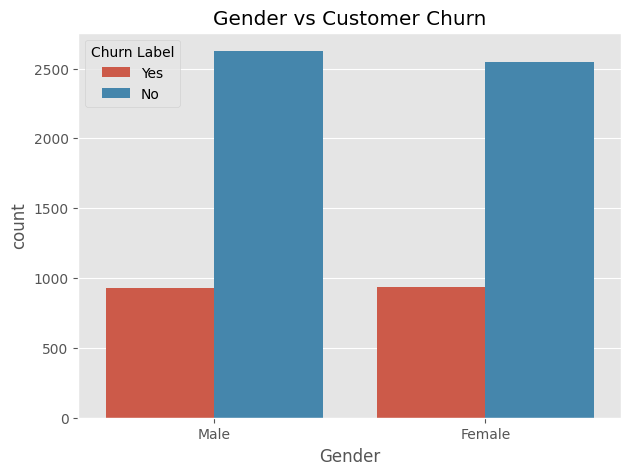

In [8]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Churn Label"
)

plt.title("Gender vs Customer Churn")

plt.show()

C:\Users\swapn\AppData\Local\Temp\ipykernel_14184\3648720602.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-Senior","Senior"])


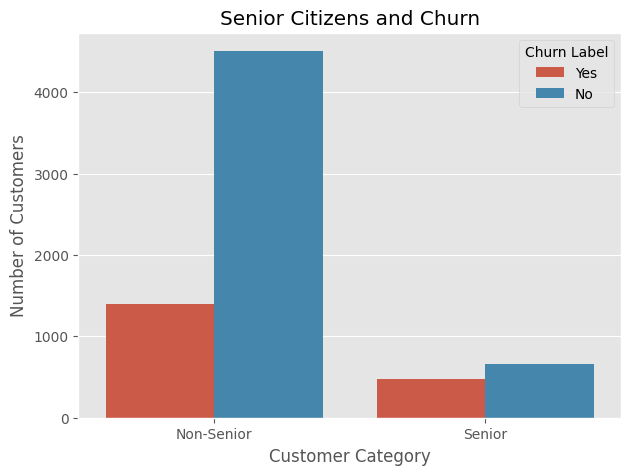

In [11]:
plt.figure(figsize=(7,5))
ax=sns.countplot(
    data=df,
    x="Senior Citizen",
    hue="Churn Label"
)
ax.set_xticklabels(["Non-Senior","Senior"])

plt.title("Senior Citizens and Churn")
plt.xlabel("Customer Category")
plt.ylabel("Number of Customers")

plt.show()

C:\Users\swapn\AppData\Local\Temp\ipykernel_14184\1634522742.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Partner","Has Partner"])


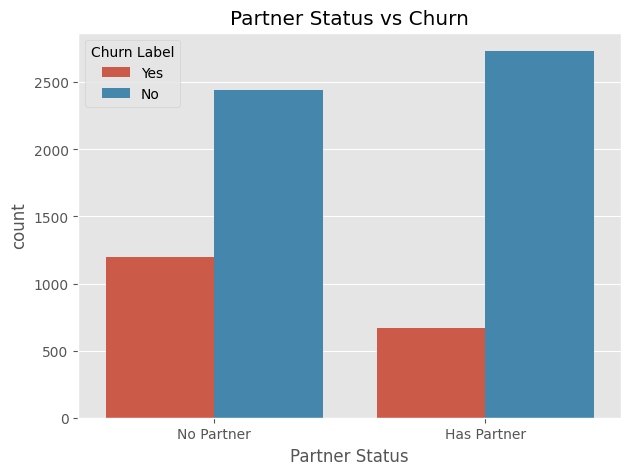

In [14]:
plt.figure(figsize=(7,5))

ax=sns.countplot(
    data=df,
    x="Partner",
    hue="Churn Label"
)
ax.set_xticklabels(["No Partner","Has Partner"])
plt.title("Partner Status vs Churn")
plt.xlabel("Partner Status")

plt.show()

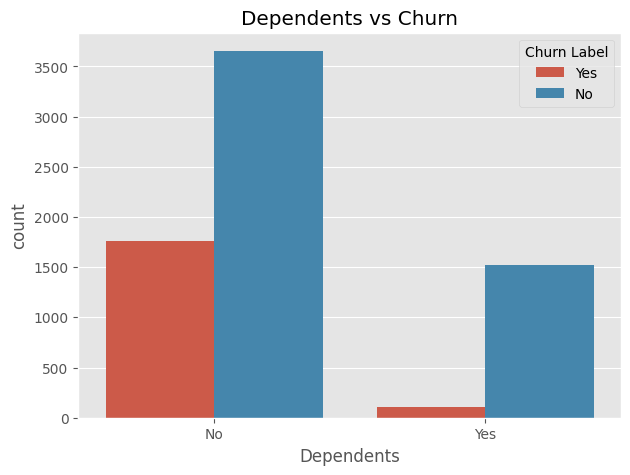

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn Label"
)

plt.title("Dependents vs Churn")

plt.show()

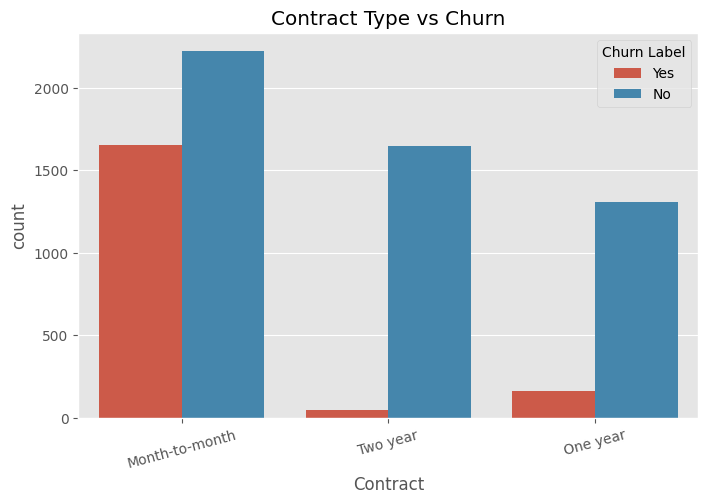

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Label"
)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=15)

plt.show()

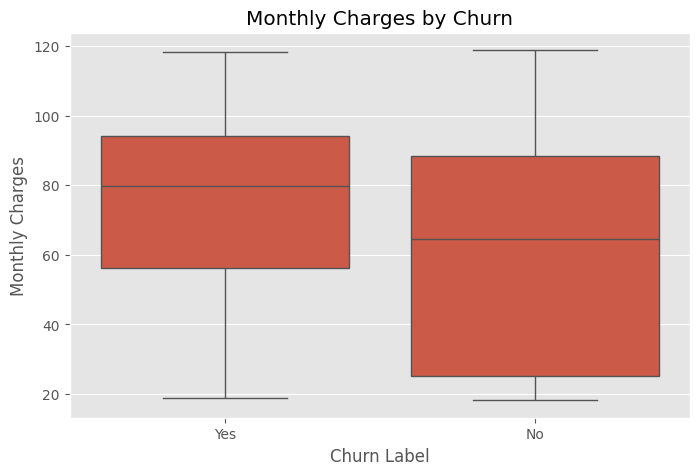

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Churn")

plt.show()

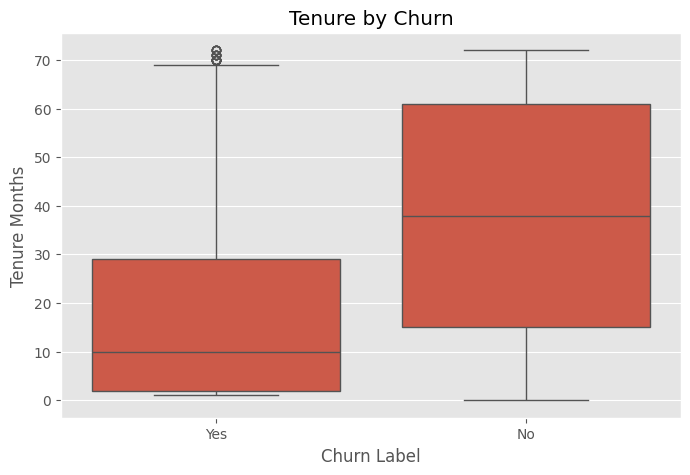

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Tenure by Churn")

plt.show()

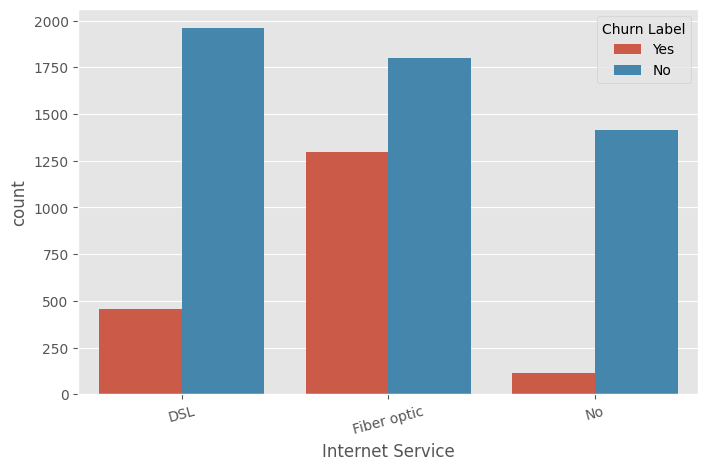

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn Label"
)

plt.xticks(rotation=15)

plt.show()

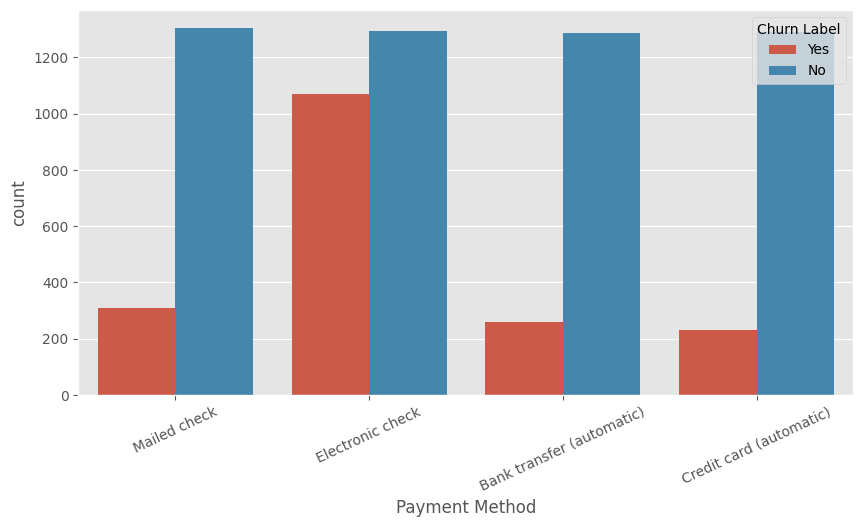

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Label"
)

plt.xticks(rotation=25)

plt.show()

In [21]:
df["Churn"] = df["Churn Label"].map({"No":0,"Yes":1})

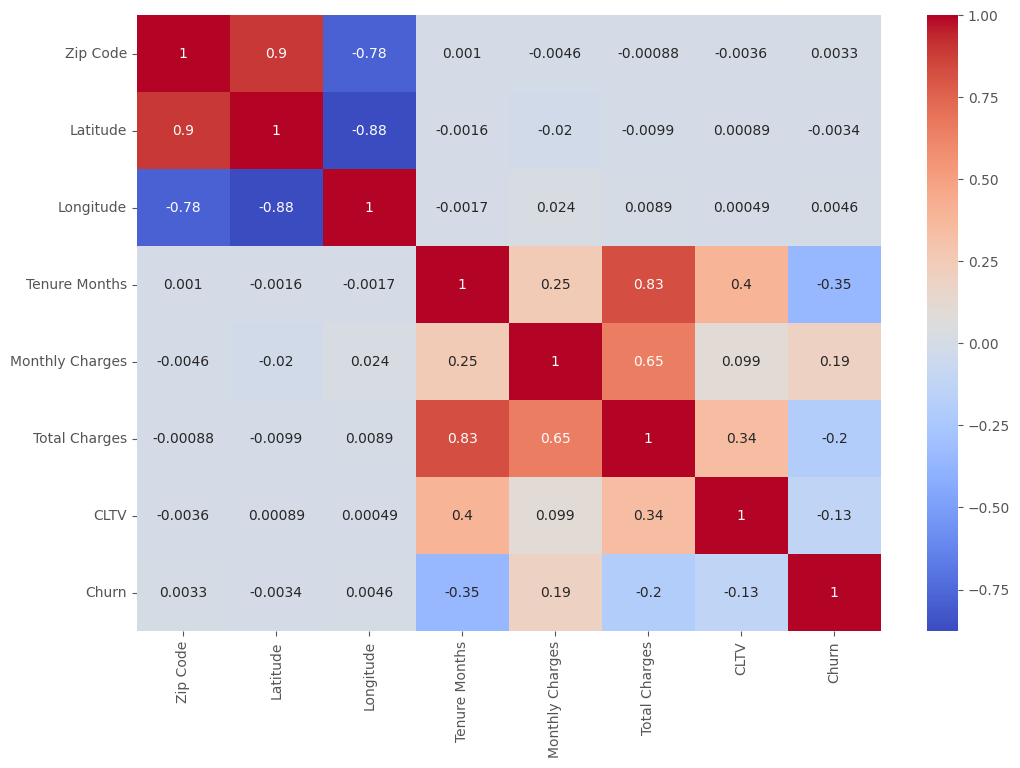

In [22]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [23]:
contract_churn = (
    df.groupby("Contract")["Churn"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print(contract_churn)

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


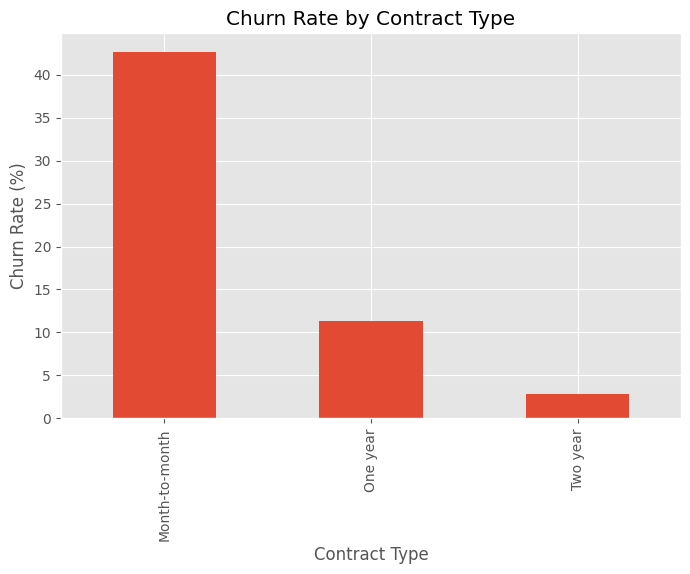

In [24]:
plt.figure(figsize=(8,5))

contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

### Insight

Month-to-month contracts have the highest churn rate.

Possible Interpretation:
Customers on flexible contracts can switch providers more easily than customers on long-term contracts.

Business Recommendation:
Encourage customers to move to yearly contracts by offering discounts and loyalty benefits.

In [25]:
internet_churn = (
    df.groupby("Internet Service")["Churn"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

internet_churn

Internet Service
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64

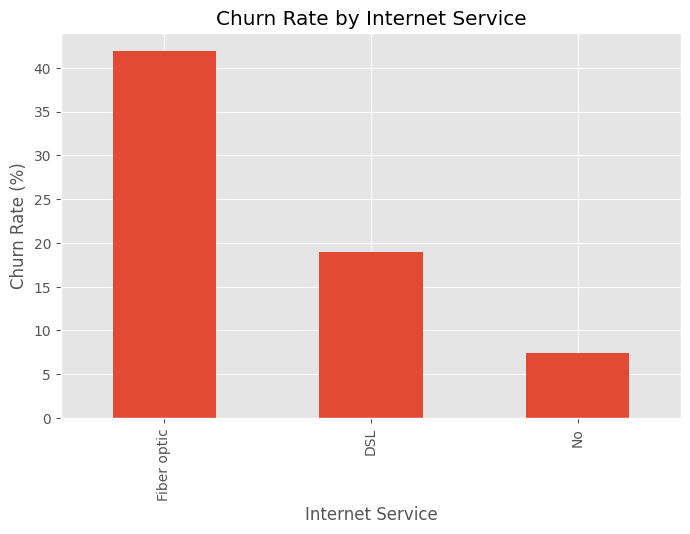

In [26]:
internet_churn.plot(kind="bar", figsize=(8,5))

plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate (%)")

plt.show()

In [27]:
payment_churn = (
    df.groupby("Payment Method")["Churn"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

payment_churn

Payment Method
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64

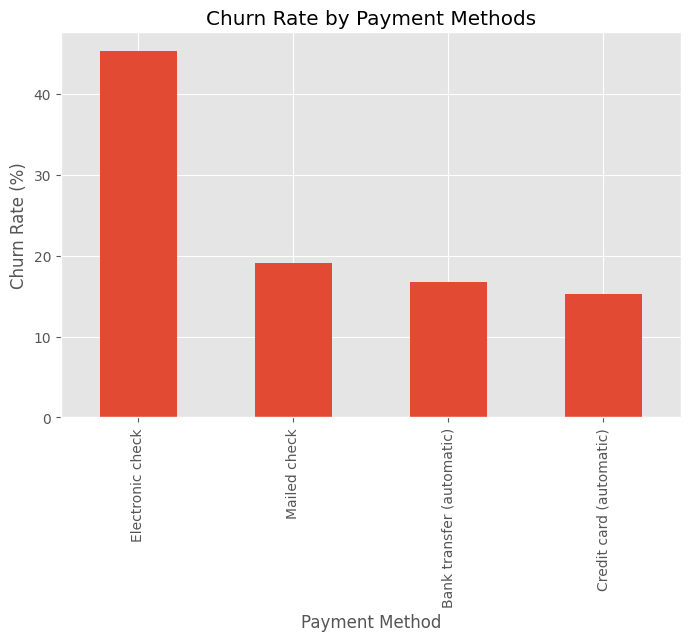

In [29]:
payment_churn.plot(kind="bar", figsize=(8,5))

plt.title("Churn Rate by Payment Methods")
plt.ylabel("Churn Rate (%)")

plt.show()

In [30]:
security_churn = (
    df.groupby("Online Security")["Churn"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

security_churn

Online Security
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn, dtype: float64

In [31]:
support_churn = (
    df.groupby("Tech Support")["Churn"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

support_churn

Tech Support
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn, dtype: float64

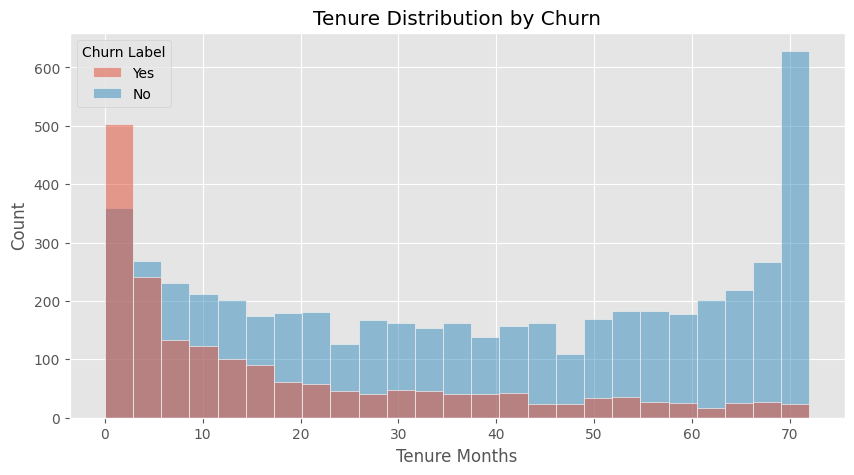

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Tenure Months",
    hue="Churn Label",
    bins=25
)

plt.title("Tenure Distribution by Churn")

plt.show()

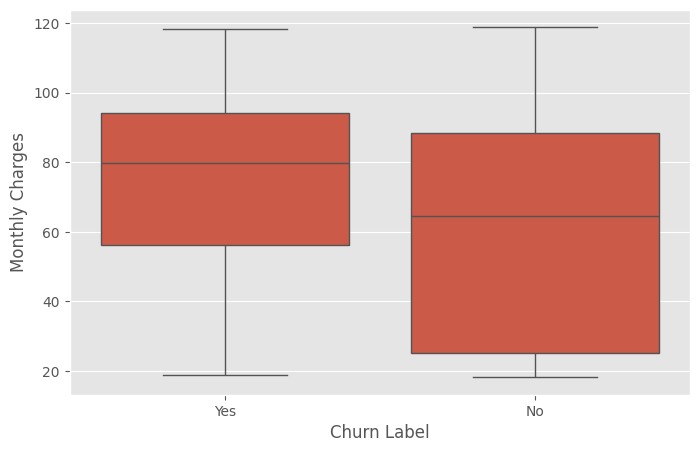

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.show()

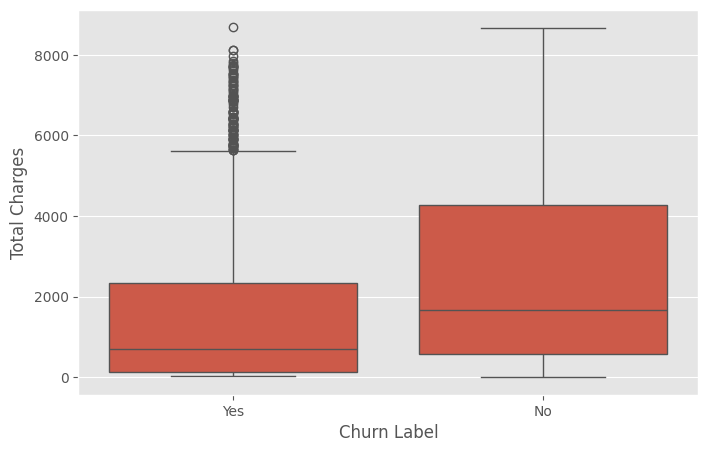

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Total Charges"
)

plt.show()

In [35]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    if col != "Churn Label":
        churn_rate = (
            df.groupby(col)["Churn"]
              .mean()
              .mul(100)
              .round(2)
              .sort_values(ascending=False)
        )

        print(f"\n{'='*50}")
        print(col)
        print(churn_rate)


City
City
Wrightwood      100.0
Tipton          100.0
Truckee         100.0
Twain           100.0
Johannesburg    100.0
                ...  
Arvin             0.0
Atascadero        0.0
Auberry           0.0
Upland            0.0
Volcano           0.0
Name: Churn, Length: 1129, dtype: float64

Lat Long
Lat Long
41.5837, -122.935922      100.0
34.437945, -119.77191     100.0
40.022184, -121.062384    100.0
34.358321, -117.618263    100.0
37.691561, -122.445202    100.0
                          ...  
37.023669, -121.946461      0.0
37.045728, -120.630682      0.0
32.733564, -117.033713      0.0
32.741852, -117.243453      0.0
41.251322, -122.105209      0.0
Name: Churn, Length: 1652, dtype: float64

Gender
Gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64

Senior Citizen
Senior Citizen
Yes    41.68
No     23.61
Name: Churn, dtype: float64

Partner
Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64

Dependents
Dependents
No     32.55
Yes     6.52
Name: Churn,